<a href="https://colab.research.google.com/github/NupoorRaut/Deep-Learning/blob/main/05_TransferLearning_Cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50, MobileNetV2, VGG16
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kshitij192/cars-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cars-image-dataset' dataset.
Path to dataset files: /kaggle/input/cars-image-dataset


In [ ]:
train_dir = "/kaggle/input/cars-image-dataset/Cars Dataset/train"
test_dir  = "/kaggle/input/cars-image-dataset/Cars Dataset/test"

img_size = (224,224)
batch_size = 32

In [ ]:
def get_generators(preprocess_func):

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_func,
        rotation_range=15,
        zoom_range=0.2,
        horizontal_flip=True
    )

    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_func
    )

    train_gen = train_datagen.flow_from_directory(
        train_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical'
    )

    test_gen = test_datagen.flow_from_directory(
        test_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False   # IMPORTANT
    )

    return train_gen, test_gen

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre

In [ ]:
def build_model(name):

    if name == "resnet":
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
        preprocess = resnet_pre

    elif name == "mobilenet":
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
        preprocess = mob_pre

    elif name == "vgg16":
        base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
        preprocess = vgg_pre

    # Freeze base
    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(base.input, output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base, preprocess

In [ ]:
def train_model(name):

    print(f"\n🚀 Training {name.upper()}")

    model, base, preprocess_func = build_model(name)

    train_gen, test_gen = get_generators(preprocess_func)

    global class_names, num_classes
    class_names = list(train_gen.class_indices.keys())
    num_classes = len(class_names)

    # Phase 1
    history = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=10
    )

    # Phase 2 (fine-tuning)
    for layer in base.layers[-30:]:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_ft = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=5
    )

    model.save(f"{name}_model.keras")

    return model, test_gen

In [ ]:
models = {}

for name in ["resnet", "mobilenet", "vgg16"]:
    model, test_gen = train_model(name)
    models[name] = (model, test_gen)


🚀 Training RESNET
Found 3352 images belonging to 7 classes.
Found 813 images belonging to 7 classes.
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 78s 630ms/step - accuracy: 0.4057 - loss: 1.6640 - val_accuracy: 0.6937 - val_loss: 1.0570
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 49s 463ms/step - accuracy: 0.5987 - loss: 1.1509 - val_accuracy: 0.7749 - val_loss: 0.7834
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 50s 476ms/step - accuracy: 0.6891 - loss: 0.9187 - val_accuracy: 0.8241 - val_loss: 0.6312
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 50s 473ms/step - accuracy: 0.7315 - loss: 0.8077 - val_accuracy: 0.8352 - val_loss: 0.5518
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 49s 470ms/step - accuracy: 0.7575 - loss: 0.7116 - val_accuracy: 0.8426 - val_loss: 0.4974
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 50s 472ms/step - accuracy: 0.7786 - loss: 0.6604 - val_accuracy: 0.8733 - val_loss: 0.4369
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 461ms/step - accuracy: 0.8058 - loss: 0.6046 - val_accuracy: 0.8721 

In [ ]:
def plot_cm(model, test_gen, name):

    y_pred = np.argmax(model.predict(test_gen), axis=1)
    y_true = test_gen.classes

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [ ]:
def report(model, test_gen):

    y_pred = np.argmax(model.predict(test_gen), axis=1)
    print(classification_report(test_gen.classes, y_pred, target_names=class_names))

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model, preprocess_func):

    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = preprocess_func(img)

    img = np.expand_dims(img, axis=0)

    pred = np.argmax(model.predict(img), axis=1)

    return class_names[pred[0]]

In [ ]:
from tensorflow.keras.models import load_model

models = {
    "ResNet": load_model("resnet_model.keras"),
    "MobileNet": load_model("mobilenet_model.keras"),
    "VGG16": load_model("vgg16_model.keras")
}

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre

test_dir = "/kaggle/input/cars-image-dataset/Cars Dataset/test"

test_datagen = ImageDataGenerator(preprocessing_function=resnet_pre)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_gen.class_indices.keys())

Found 813 images belonging to 7 classes.


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

results = []

for name, model in models.items():

    y_pred = np.argmax(model.predict(test_gen), axis=1)
    y_true = test_gen.classes

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 242ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step


In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results)

       Model  Accuracy  Precision    Recall  F1 Score
0     ResNet  0.944649   0.944731  0.944649  0.944230
1  MobileNet  0.319803   0.476921  0.319803  0.321385
2      VGG16  0.947109   0.948234  0.947109  0.947125


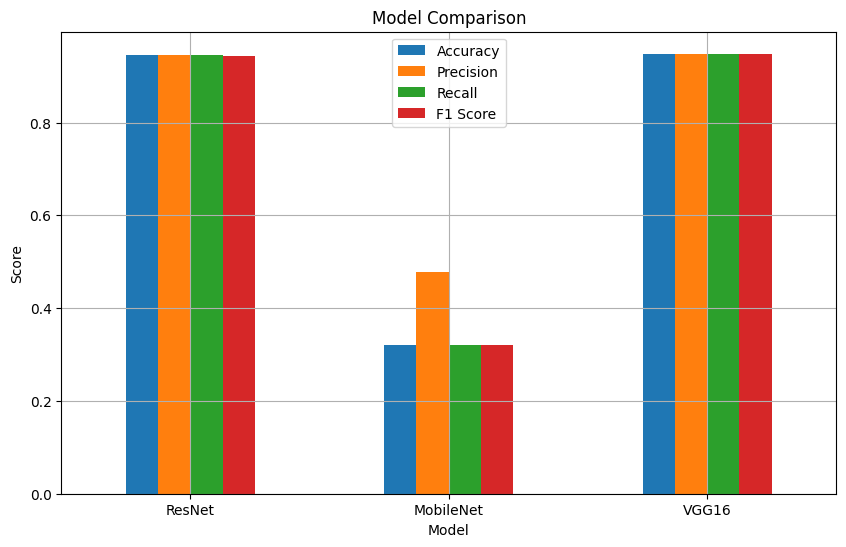

In [ ]:
import matplotlib.pyplot as plt

df_results.set_index("Model").plot(kind='bar', figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()
plt.show()

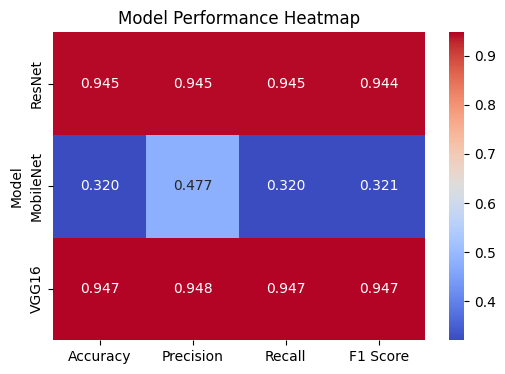

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df_results.set_index("Model"), annot=True, cmap="coolwarm", fmt=".3f")

plt.title("Model Performance Heatmap")
plt.show()